# HMM Baseline for WLASL Sign Recognition - v2 (corrected)

Notebook `02_hmm_wlasl_baseline.ipynb` scored **accuracy 0.2353**, which is exactly
the majority-class baseline (4 of 17). It predicted the single class `before` for
every test video. This notebook fixes that.

## Root cause, in three layers

**1. Development bug (the direct cause).** Four of the five per-class HMMs trained
degenerately - the v1 log shows `Some rows of transmat_ have zero sum because no
transition from the state was ever observed` for `computer`, `cool`, `cousin` and
`drink`, but *not* for `before`. A zero-sum transition row makes `model.score()`
return `-inf`. The v1 prediction code then did:

```python
return max(scores, key=scores.get)     # every value is -inf
```

When all values tie, Python returns the **first inserted key**, which is class id 0,
which `LabelEncoder` assigned alphabetically to `before`. The guard `if not scores:`
never fired because the dict always had 5 entries - hence `Valid predictions: 17 out of 17`.

**2. Data / feature design.** The frame vector was 1629-D, of which **1404 (86.2%) was
face landmarks**. `StandardScaler` weights all dimensions equally, so PCA modelled
facial geometry and head pose - not the hands, which is where these glosses differ.
Missing hands were zero-filled, which after scaling became large-magnitude outliers,
so PCA also spent capacity modelling detector dropout.

**3. Model capacity.** `GaussianHMM(n_components=5, covariance_type="diag")` at D=30 has
150 means + 150 variances + 25 transitions + 5 start probabilities = **330 free
parameters per class**, fitted to roughly 10 sequences x 35 frames = 350 highly
autocorrelated frames. The zero-sum warnings were the model reporting that it had no data.

## What changed

| Area | v1 | v2 |
|---|---|---|
| Frame features | 1629-D, 86% face | 309-D: upper-body pose + hands + presence flags + velocity |
| Coordinates | raw image-relative | centred on mid-shoulder, scaled by shoulder width |
| Missing hands | zero-fill (becomes an outlier) | left at body origin + explicit binary flag |
| PCA components | 30 | 16 |
| HMM topology | ergodic, 5 states | left-to-right (Bakis), 3 states, transitions fixed |
| Free params / class | 330 | 96 |
| Prediction | `max()` -> silent class 0 | finite check, length-normalised, explicit abstain |
| Evaluation | one 17-sample holdout | 5-fold stratified CV, out-of-fold, per-fold SD |
| Reference baseline | none | DTW + 1-NN |

MediaPipe extraction is **unchanged and reused from cache** - it does not re-run.

## 1. Imports

In [1]:
import os
import sys
import json
import logging
import warnings
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
import joblib

import fiftyone as fo
import fiftyone.utils.huggingface as fouh

import mediapipe as mp
from hmmlearn.hmm import GaussianHMM

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)

print("numpy      :", np.__version__)
print("notebook   : 022_hmm_wlasl_baselin (v2, corrected)")

numpy      : 1.26.4
notebook   : 022_hmm_wlasl_baselin (v2, corrected)


## 2. Configuration, logging and error codes

Every failure raises an exception carrying a stable code (`HMM-1001`, `HMM-2001`, ...)
so log files stay greppable. v1 relied on bare exceptions and silent `continue`s,
which is how four broken models reached prediction time unnoticed.

In [2]:
PROJECT_DIR = Path("ksl_project_data").resolve()
LOG_DIR     = PROJECT_DIR / "logs"
FEATURE_DIR = PROJECT_DIR / "features"
MODEL_DIR   = PROJECT_DIR / "models"
REPORT_DIR  = PROJECT_DIR / "reports"

for folder in [PROJECT_DIR, LOG_DIR, FEATURE_DIR, MODEL_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

log_file = LOG_DIR / f"hmm_v2_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(message)s",
    handlers=[logging.FileHandler(log_file), logging.StreamHandler(sys.stdout)],
    force=True,
)
logger = logging.getLogger("hmm_v2")

# MediaPipe/absl are extremely chatty; keep the notebook readable.
logging.getLogger("absl").setLevel(logging.ERROR)
os.environ.setdefault("GLOG_minloglevel", "2")


class PipelineError(RuntimeError):
    """Base error carrying a stable code for log grepping."""
    code = "HMM-0000"
    def __init__(self, message):
        super().__init__(f"[{self.code}] {message}")

class CacheMissingError(PipelineError):      code = "HMM-1001"
class CacheShapeError(PipelineError):        code = "HMM-1002"
class InsufficientDataError(PipelineError):  code = "HMM-1003"


# ---- Hyperparameters -------------------------------------------------------
RANDOM_STATE      = 42
N_CLASSES         = 8       # requested; classes with no usable video are dropped
MIN_SAMPLES_PER_CLASS = 5
MAX_SAMPLES_PER_CLASS = 40

MAX_FRAMES        = 60
FRAME_STRIDE      = 2

N_PCA_COMPONENTS  = 16      # v1 used 30
N_HMM_STATES      = 3       # v1 used 5
N_ITER            = 200
MIN_COVAR         = 1e-3    # variance floor - v1 had none
TRAIN_TRANSITIONS = False   # see section 6 (ADR-005)
N_FOLDS           = 5

np.random.seed(RANDOM_STATE)

logger.info("HMM v2 notebook started")
print("Project directory:", PROJECT_DIR)
print("Log file         :", log_file)

2026-08-16 12:39:50,248 | INFO    | HMM v2 notebook started
Project directory: /workspace/dataset/ipynb_checkpoints/ksl_project_data
Log file         : /workspace/dataset/ipynb_checkpoints/ksl_project_data/logs/hmm_v2_20260816_123950.log


## 3. Load the WLASL dataset (unchanged from v1)

In [4]:
DATASET_NAME = "Voxel51/WLASL"

if DATASET_NAME in fo.list_datasets():
    logger.info("Loading existing local WLASL dataset")
    dataset = fo.load_dataset(DATASET_NAME)
else:
    logger.info("Loading WLASL from Hugging Face / FiftyOne hub")
    dataset = fouh.load_from_hub(DATASET_NAME, persistent=True)

dataset.persistent = True

logger.info("Dataset loaded: %s", dataset.name)
logger.info("Total samples: %d", len(dataset))

print("Dataset      :", dataset.name)
print("Total samples:", len(dataset))

2026-08-16 12:40:18,690 | INFO    | Loading existing local WLASL dataset
2026-08-16 12:40:18,707 | INFO    | Dataset loaded: Voxel51/WLASL
2026-08-16 12:40:18,711 | INFO    | Total samples: 11980
Dataset      : Voxel51/WLASL
Total samples: 11980


## 4. Label extraction helper (unchanged from v1)

In [5]:
def get_label_from_sample(sample):
    """Return the gloss string for a FiftyOne sample, or None."""
    candidate_fields = ["ground_truth", "label", "labels", "classification", "word", "gloss"]

    for field in candidate_fields:
        if field in sample:
            value = sample[field]
            if value is None:
                continue
            if hasattr(value, "label"):
                return value.label
            if isinstance(value, str):
                return value

    for field in sample.field_names:
        value = sample[field]
        if hasattr(value, "label"):
            return value.label
        if field.lower() in ["word", "gloss", "label"] and isinstance(value, str):
            return value

    return None


labels = []
missing_label_count = 0

for sample in dataset:
    label = get_label_from_sample(sample)
    if label is None:
        missing_label_count += 1
    else:
        labels.append(label)

label_counts = Counter(labels)

print("Samples with labels   :", len(labels))
print("Samples missing labels:", missing_label_count)
print("Unique labels         :", len(label_counts))
print()
print("Top 15 labels:")
for label, count in label_counts.most_common(15):
    print(f"  {label:<16s} {count}")

Samples with labels   : 11980
Samples missing labels: 0
Unique labels         : 2000

Top 15 labels:
  before           16
  cool             16
  thin             16
  drink            15
  go               15
  computer         14
  cousin           14
  help             14
  who              14
  accident         13
  bed              13
  bowling          13
  candy            13
  short            13
  tall             13


## 5. Class selection - with a data-availability audit

v1 requested 8 classes but silently ended up with 5. `thin`, `go` and `help` each had
14-16 labelled entries yet **zero** files passing `Path(sample.filepath).exists()`.
An all-or-nothing pattern like that is a download failure, not random missingness -
roughly 45 videos that should be available.

This cell makes that loss explicit instead of letting it pass unnoticed.

In [6]:
eligible_labels = [lab for lab, cnt in label_counts.most_common() if cnt >= MIN_SAMPLES_PER_CLASS]
requested_labels = eligible_labels[:N_CLASSES]
requested_set = set(requested_labels)

selected_samples = []
per_class_usable = Counter()
per_class_requested = {lab: label_counts[lab] for lab in requested_labels}

for sample in dataset:
    label = get_label_from_sample(sample)
    if label in requested_set and per_class_usable[label] < MAX_SAMPLES_PER_CLASS:
        if sample.filepath and Path(sample.filepath).exists():
            selected_samples.append(sample)
            per_class_usable[label] += 1

print("=" * 64)
print("DATA AVAILABILITY AUDIT")
print("=" * 64)
print(f"{'gloss':<16s}{'labelled':>10s}{'on disk':>10s}{'missing':>10s}")
print("-" * 64)

total_labelled = total_usable = 0
dropped_classes = []
for lab in requested_labels:
    have, want = per_class_usable[lab], per_class_requested[lab]
    total_labelled += want
    total_usable += have
    flag = "   <-- DROPPED (no video files)" if have == 0 else ""
    if have == 0:
        dropped_classes.append(lab)
    print(f"{lab:<16s}{want:>10d}{have:>10d}{want - have:>10d}{flag}")

print("-" * 64)
print(f"{'TOTAL':<16s}{total_labelled:>10d}{total_usable:>10d}{total_labelled - total_usable:>10d}")
print()

if dropped_classes:
    logger.warning(
        "[HMM-1004] %d class(es) dropped for having zero video files on disk: %s. "
        "Check download_wlasl.py - this is recoverable data.",
        len(dropped_classes), dropped_classes,
    )

print("Classes usable      :", sorted(set(per_class_usable) - set(dropped_classes)))
print("Usable video samples:", len(selected_samples))

if len(selected_samples) < 10:
    raise InsufficientDataError(
        f"Only {len(selected_samples)} usable videos found. Fix the download first."
    )

DATA AVAILABILITY AUDIT
gloss             labelled   on disk   missing
----------------------------------------------------------------
before                  16        15         1
cool                    16         0        16   <-- DROPPED (no video files)
thin                    16         0        16   <-- DROPPED (no video files)
drink                   15         0        15   <-- DROPPED (no video files)
go                      15         0        15   <-- DROPPED (no video files)
computer                14         0        14   <-- DROPPED (no video files)
cousin                  14         0        14   <-- DROPPED (no video files)
help                    14         0        14   <-- DROPPED (no video files)
----------------------------------------------------------------
TOTAL                  120        15       105

2026-08-16 12:42:34,553 | WARNING | [HMM-1004] 7 class(es) dropped for having zero video files on disk: ['cool', 'thin', 'drink', 'go', 'computer', 'cousin', 

## 6. MediaPipe landmark extraction (unchanged from v1)

Kept byte-for-byte compatible with v1 so the existing cache
`ksl_project_data/features/wlasl_hmm_sequences.joblib` is reused directly.
The 1629-D frame layout is fixed and known:

| Block | Slice | Dims |
|---|---|---|
| pose | `[0:99]` | 33 landmarks x (x, y, z) |
| left hand | `[99:162]` | 21 landmarks x (x, y, z) |
| right hand | `[162:225]` | 21 landmarks x (x, y, z) |
| face | `[225:1629]` | 468 landmarks x (x, y, z) |

Section 7 slices the face block off, so **MediaPipe does not need to re-run.**

In [7]:
mp_holistic = mp.solutions.holistic

POSE_LANDMARKS = 33
HAND_LANDMARKS = 21
FACE_LANDMARKS = 468
FEATURES_PER_LANDMARK = 3


def flatten_landmarks(landmarks, expected_count):
    """Flatten a MediaPipe landmark list to a fixed-length vector (zeros if absent)."""
    if landmarks is None:
        return np.zeros(expected_count * FEATURES_PER_LANDMARK, dtype=np.float32)

    values = []
    for lm in landmarks.landmark[:expected_count]:
        values.extend([lm.x, lm.y, lm.z])

    expected_length = expected_count * FEATURES_PER_LANDMARK
    if len(values) < expected_length:
        values.extend([0.0] * (expected_length - len(values)))

    return np.array(values[:expected_length], dtype=np.float32)


def extract_video_landmark_sequence(video_path, max_frames=MAX_FRAMES, frame_stride=FRAME_STRIDE):
    """Return a (T, 1629) float32 array of per-frame landmarks, or None."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    sequence = []
    frame_index = 0

    with mp_holistic.Holistic(
        static_image_mode=False,
        model_complexity=1,
        enable_segmentation=False,
        refine_face_landmarks=False,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    ) as holistic:
        while cap.isOpened() and len(sequence) < max_frames:
            success, frame = cap.read()
            if not success:
                break

            if frame_index % frame_stride != 0:
                frame_index += 1
                continue

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic.process(rgb)

            pose       = flatten_landmarks(results.pose_landmarks, POSE_LANDMARKS)
            left_hand  = flatten_landmarks(results.left_hand_landmarks, HAND_LANDMARKS)
            right_hand = flatten_landmarks(results.right_hand_landmarks, HAND_LANDMARKS)
            face       = flatten_landmarks(results.face_landmarks, FACE_LANDMARKS)

            sequence.append(np.concatenate([pose, left_hand, right_hand, face]))
            frame_index += 1

    cap.release()

    if len(sequence) == 0:
        return None

    return np.vstack(sequence).astype(np.float32)


print("Extractor ready. Frame vector size:",
      (POSE_LANDMARKS + 2 * HAND_LANDMARKS + FACE_LANDMARKS) * FEATURES_PER_LANDMARK)

Extractor ready. Frame vector size: 1629


## 7. Load the cached sequences (or extract them once)

In [8]:
HMM_SEQUENCE_CACHE = FEATURE_DIR / "wlasl_hmm_sequences.joblib"
EXPECTED_RAW_DIM = 1629


def validate_sequences(sequences, seq_labels):
    """Fail loudly on a malformed cache instead of producing silent garbage."""
    if len(sequences) != len(seq_labels):
        raise CacheShapeError(
            f"{len(sequences)} sequences vs {len(seq_labels)} labels."
        )
    if not sequences:
        raise InsufficientDataError("Zero sequences available.")

    for i, seq in enumerate(sequences):
        arr = np.asarray(seq)
        if arr.ndim != 2:
            raise CacheShapeError(f"Sequence {i}: ndim={arr.ndim}, expected 2.")
        if arr.shape[1] != EXPECTED_RAW_DIM:
            raise CacheShapeError(
                f"Sequence {i}: {arr.shape[1]} features, expected {EXPECTED_RAW_DIM}."
            )
        if arr.shape[0] < 2:
            raise CacheShapeError(
                f"Sequence {i}: only {arr.shape[0]} frame(s); need >= 2 for velocity."
            )
    return True


if HMM_SEQUENCE_CACHE.exists():
    logger.info("Loading cached sequences from %s", HMM_SEQUENCE_CACHE)
    cached = joblib.load(HMM_SEQUENCE_CACHE)
    sequences = list(cached["sequences"])
    sequence_labels = list(cached["labels"])
else:
    logger.info("No cache found - extracting landmark sequences with MediaPipe")
    sequences, sequence_labels, failed = [], [], []

    for index, sample in enumerate(selected_samples, start=1):
        label = get_label_from_sample(sample)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                seq = extract_video_landmark_sequence(sample.filepath)
            if seq is None:
                failed.append((sample.filepath, "no landmarks"))
                continue
            sequences.append(seq)
            sequence_labels.append(label)
        except Exception as exc:
            failed.append((sample.filepath, str(exc)))
            logger.warning("[HMM-1005] Failed %s: %s", sample.filepath, exc)

        if index % 10 == 0:
            logger.info("Processed %d/%d videos", index, len(selected_samples))

    joblib.dump({"sequences": sequences, "labels": sequence_labels}, HMM_SEQUENCE_CACHE)
    logger.info("Saved cache: %s (failed: %d)", HMM_SEQUENCE_CACHE, len(failed))

sequences = [np.asarray(s, dtype=np.float64) for s in sequences]
validate_sequences(sequences, sequence_labels)

lengths = [len(s) for s in sequences]
print("Sequences        :", len(sequences))
print("Raw frame dim    :", sequences[0].shape[1])
print("Sequence length  : min=%d  median=%d  max=%d" % (
    min(lengths), int(np.median(lengths)), max(lengths)))
print("Classes          :", sorted(set(sequence_labels)))
print("Per-class counts :", dict(Counter(sequence_labels)))

2026-08-16 12:44:52,491 | INFO    | Loading cached sequences from /workspace/dataset/ipynb_checkpoints/ksl_project_data/features/wlasl_hmm_sequences.joblib
Sequences        : 67
Raw frame dim    : 1629
Sequence length  : min=12  median=34  max=60
Classes          : ['before', 'computer', 'cool', 'cousin', 'drink']
Per-class counts : {'before': 15, 'computer': 14, 'cool': 13, 'cousin': 13, 'drink': 12}


## 8. Feature engineering - the largest change

### ADR-001: discard the face block
Face is 1404 / 1629 = **86.2%** of every v1 frame vector. `StandardScaler` gives all
dimensions equal weight, so PCA's leading components described facial geometry and
head pose. `before` / `computer` / `cool` / `cousin` / `drink` are disambiguated by
**hand shape and hand trajectory**. Dropping face raises the signal fraction of the
input from ~14% to ~100%.
*Rejected alternative:* down-weighting face - introduces a hyperparameter with no
data to tune it on (50 training sequences).

### ADR-002: explicit presence flags instead of zero-fill
`flatten_landmarks` returns zeros when MediaPipe misses a hand. Downstream,
`StandardScaler` maps `0.0` to `(0 - mean) / std`, and since MediaPipe x/y are
image-normalised with mean ~0.5, a missing hand became a **large-magnitude outlier**
rather than a neutral value. PCA then spent leading components modelling detector
dropout. v2 normalises only observed blocks, leaves missing blocks at exact zero
*after* centring (zero now means "at body centre" - genuinely neutral), and exposes
missingness as 3 explicit binary channels the model can use.

### ADR-003: body-centred, shoulder-scaled coordinates
Raw MediaPipe x/y are image-relative, so signer position in frame and camera distance
vary more across WLASL clips than the signs do. v2 translates to the mid-shoulder
point and divides by inter-shoulder distance, giving translation and scale invariance.

### ADR-004: velocity (delta) features
A Gaussian HMM emission describes one *static* frame, but sign identity lives largely
in motion. First-order differences are the standard cheap fix (cf. delta-cepstra in
speech HMMs). Second-order deltas are omitted - too noisy at ~35 frames/sequence.

**Result: 1629-D -> 309-D**, of which 100% is hand/upper-body information.

In [10]:
# --- cached frame layout (fixed, known) ---
POSE_OFF, POSE_D = 0,   99     # 33 landmarks * 3
LH_OFF,   LH_D   = 99,  63     # 21 landmarks * 3
RH_OFF,   RH_D   = 162, 63     # 21 landmarks * 3
FACE_OFF, FACE_D = 225, 1404   # 468 landmarks * 3 -- DISCARDED (ADR-001)

assert POSE_D + LH_D + RH_D + FACE_D == EXPECTED_RAW_DIM

# MediaPipe Pose indices we keep:
#   0 nose | 11,12 shoulders | 13,14 elbows | 15,16 wrists | 23,24 hips
UPPER_POSE_IDX = [0, 11, 12, 13, 14, 15, 16, 23, 24]
L_SHOULDER, R_SHOULDER = 11, 12

N_COORD_DIMS = len(UPPER_POSE_IDX) * 3 + LH_D + RH_D   # 27 + 63 + 63 = 153
N_FLAG_DIMS  = 3                                       # pose / left / right present
N_BASE_DIMS  = N_COORD_DIMS + N_FLAG_DIMS              # 156
N_FULL_DIMS  = N_BASE_DIMS + N_COORD_DIMS              # 156 + 153 = 309

print(f"face share of v1 vector : {100 * FACE_D / EXPECTED_RAW_DIM:.1f}%")
print(f"N_COORD_DIMS            : {N_COORD_DIMS}")
print(f"N_BASE_DIMS             : {N_BASE_DIMS}")
print(f"N_FULL_DIMS (with delta): {N_FULL_DIMS}")
print(f"reduction               : {EXPECTED_RAW_DIM} -> {N_FULL_DIMS}")

face share of v1 vector : 86.2%
N_COORD_DIMS            : 153
N_BASE_DIMS             : 156
N_FULL_DIMS (with delta): 309
reduction               : 1629 -> 309


In [12]:
def _block_present(block):
    """The extractor encodes a MediaPipe miss as an exact all-zero block."""
    return bool(np.any(block != 0.0))


def normalise_frame(raw_frame, fallback):
    """
    Convert one raw 1629-D frame into a 156-D body-centred descriptor.

    Returns (feature_156, new_fallback), where new_fallback is the
    (origin_xy, scale) pair to reuse if the next frame has no pose detection.
    """
    pose = raw_frame[POSE_OFF:POSE_OFF + POSE_D].reshape(33, 3)
    lh   = raw_frame[LH_OFF:LH_OFF + LH_D].reshape(21, 3)
    rh   = raw_frame[RH_OFF:RH_OFF + RH_D].reshape(21, 3)
    # face block deliberately not read -- ADR-001

    pose_present = _block_present(pose)
    lh_present   = _block_present(lh)
    rh_present   = _block_present(rh)

    # --- body frame of reference (ADR-003) ---
    if pose_present:
        ls_xy = pose[L_SHOULDER, :2]
        rs_xy = pose[R_SHOULDER, :2]
        origin_xy = (ls_xy + rs_xy) / 2.0
        scale = float(np.linalg.norm(ls_xy - rs_xy))
        if not np.isfinite(scale) or scale < 1e-6:
            # shoulders coincide: profile view or bad detection
            origin_xy, scale = fallback
        new_fallback = (origin_xy, scale)
    else:
        origin_xy, scale = fallback
        new_fallback = fallback

    def _norm(block, present):
        # ADR-002: missing blocks stay at exact zero, which after centring means
        # "at body origin" -- neutral, not an outlier.
        if not present:
            return np.zeros_like(block)
        out = np.empty_like(block)
        out[:, 0] = (block[:, 0] - origin_xy[0]) / scale
        out[:, 1] = (block[:, 1] - origin_xy[1]) / scale
        out[:, 2] = block[:, 2] / scale
        return out

    pose_n = _norm(pose, pose_present)[UPPER_POSE_IDX]   # (9, 3)
    lh_n   = _norm(lh, lh_present)                        # (21, 3)
    rh_n   = _norm(rh, rh_present)                        # (21, 3)

    coords = np.concatenate([pose_n.ravel(), lh_n.ravel(), rh_n.ravel()])
    flags = np.array([float(pose_present), float(lh_present), float(rh_present)])
    feature = np.concatenate([coords, flags])

    assert feature.shape[0] == N_BASE_DIMS, (feature.shape, N_BASE_DIMS)
    return feature, new_fallback


def build_sequence_features(raw_sequence):
    """Raw (T, 1629) -> engineered (T, 309) including velocity channels."""
    fallback = (np.array([0.5, 0.5]), 1.0)   # image centre, unit scale
    base = np.empty((raw_sequence.shape[0], N_BASE_DIMS), dtype=np.float64)

    for t in range(raw_sequence.shape[0]):
        base[t], fallback = normalise_frame(raw_sequence[t], fallback)

    # ADR-004: first-order differences over coordinate channels only (not flags)
    coords = base[:, :N_COORD_DIMS]
    delta = np.zeros_like(coords)
    delta[1:] = np.diff(coords, axis=0)

    full = np.concatenate([base, delta], axis=1)
    assert full.shape[1] == N_FULL_DIMS, (full.shape, N_FULL_DIMS)

    if not np.all(np.isfinite(full)):
        n_bad = int((~np.isfinite(full)).sum())
        logger.warning("[HMM-1006] %d non-finite values in sequence; zeroing.", n_bad)
        full = np.nan_to_num(full, nan=0.0, posinf=0.0, neginf=0.0)

    return full


print("Feature functions defined.")

Feature functions defined.


### 8b. Build features and audit landmark detection rates

The detection-rate readout below did not exist in v1 and is worth watching. If a hand
is only found in, say, 40% of frames, no model architecture will rescue that - it is a
video-quality problem to fix upstream.

In [13]:
logger.info("Building corrected features (%d -> %d dims per frame)...",
            EXPECTED_RAW_DIM, N_FULL_DIMS)

features = [build_sequence_features(s) for s in sequences]

all_flags = np.vstack([f[:, N_COORD_DIMS:N_COORD_DIMS + N_FLAG_DIMS] for f in features])
detection = {
    "pose":       100 * all_flags[:, 0].mean(),
    "left_hand":  100 * all_flags[:, 1].mean(),
    "right_hand": 100 * all_flags[:, 2].mean(),
}

print("=" * 64)
print("LANDMARK DETECTION RATE (across all frames)")
print("=" * 64)
for name, pct in detection.items():
    bar = "#" * int(pct / 2)
    warn = "   <-- LOW" if pct < 50 else ""
    print(f"  {name:<12s}{pct:6.1f}%  {bar}{warn}")
print()

for name, pct in detection.items():
    if pct < 50:
        logger.warning(
            "[HMM-1007] %s detected in only %.1f%% of frames. This caps achievable "
            "accuracy regardless of model choice.", name, pct)

print("Feature sequences :", len(features))
print("Frame feature dim :", features[0].shape[1])
print("Example shape     :", features[0].shape)

2026-08-16 12:46:12,775 | INFO    | Building corrected features (1629 -> 309 dims per frame)...
LANDMARK DETECTION RATE (across all frames)
  pose          99.6%  #################################################
  left_hand     22.6%  ###########   <-- LOW
  right_hand    62.3%  ###############################

2026-08-16 12:46:13,061 | WARNING | [HMM-1007] left_hand detected in only 22.6% of frames. This caps achievable accuracy regardless of model choice.
Feature sequences : 67
Frame feature dim : 309
Example shape     : (44, 309)


## 9. HMM construction

### ADR-005: fixed left-to-right (Bakis) transition matrix

Signs are **monotonic** - preparation, stroke, retraction; you never return to the
wind-up after the follow-through. An ergodic 5-state HMM must estimate 25 transition
probabilities from ~350 highly autocorrelated frames per class. v1 proves this fails:
hmmlearn emitted `Some rows of transmat_ have zero sum because no transition from the
state was ever observed` for 4 of 5 classes, which is exactly what makes `score()`
return `-inf`.

**Ergodic (v1)** - any stage may follow any stage:

```
        S0    S1    S2    S3    S4
  S0     ?     ?     ?     ?     ?
  S1     ?     ?     ?     ?     ?          20 free numbers
  S2     ?     ?     ?     ?     ?        + 4 free start probs
  S3     ?     ?     ?     ?     ?        = 24 to estimate
  S4     ?     ?     ?     ?     ?
```

**Bakis (v2)** - stay, or advance one stage:

```
        S0    S1    S2
  S0   stay  next    0
  S1     0   stay  next                    0 free numbers
  S2     0     0   stay                    (held fixed)
```

v2 fixes `startprob_` and `transmat_` to this prior and trains **only** the Gaussian
emissions (`params="mc"`), removing 24 free parameters per class and making zero-sum
rows structurally impossible.

| | v1 | v2 |
|---|---|---|
| means | 5 x 30 = 150 | 3 x 16 = 48 |
| variances | 5 x 30 = 150 | 3 x 16 = 48 |
| transitions + start | 30 | 0 (fixed) |
| **total per class** | **330** | **96** |
| training frames per class | ~350 | ~350 |

Set `TRAIN_TRANSITIONS = True` (section 2) once you have 30+ sequences per class;
`sanitise_hmm` will then repair any zero rows rather than letting them become `-inf`.

`min_covar` is also new: without a variance floor a state can collapse to zero
variance, sending its density to `+inf` and letting one class hijack every prediction.

In [14]:
def left_to_right_transmat(n_states, self_loop=0.7):
    """Bakis topology: stay in state i, or advance to i+1. Last state absorbing."""
    if n_states < 1:
        raise ValueError("n_states must be >= 1")
    t = np.zeros((n_states, n_states), dtype=np.float64)
    for i in range(n_states - 1):
        t[i, i]     = self_loop
        t[i, i + 1] = 1.0 - self_loop
    t[n_states - 1, n_states - 1] = 1.0
    return t


def build_hmm(n_states=N_HMM_STATES, n_iter=N_ITER, train_transitions=TRAIN_TRANSITIONS):
    model = GaussianHMM(
        n_components=n_states,
        covariance_type="diag",   # "full" is singular at this data scale
        min_covar=MIN_COVAR,      # variance floor -> blocks +inf densities
        n_iter=n_iter,
        tol=1e-4,
        init_params="mc",                             # kmeans-init means/covars
        params="mct" if train_transitions else "mc",  # ADR-005
        random_state=RANDOM_STATE,
        verbose=False,
    )
    model.startprob_ = np.eye(n_states)[0]            # always begin in state 0
    model.transmat_  = left_to_right_transmat(n_states)
    return model


def sanitise_hmm(model):
    """Guarantee score() cannot return -inf/NaN for structural reasons."""
    n = model.n_components

    start = np.asarray(model.startprob_, dtype=np.float64)
    if not np.all(np.isfinite(start)) or start.sum() <= 0:
        start = np.full(n, 1.0 / n)
    start = np.clip(start, 1e-8, None)
    model.startprob_ = start / start.sum()

    trans = np.asarray(model.transmat_, dtype=np.float64).copy()
    trans[~np.isfinite(trans)] = 0.0
    for i in range(n):
        if trans[i].sum() <= 0:
            logger.warning("[HMM-2002] Repairing zero-sum transmat row %d.", i)
            trans[i] = 1.0 / n
    trans = np.clip(trans, 1e-8, None)
    model.transmat_ = trans / trans.sum(axis=1, keepdims=True)

    if hasattr(model, "_covars_") and model._covars_ is not None:
        model._covars_ = np.clip(np.asarray(model._covars_), MIN_COVAR, None)

    return model


def fit_class_models(train_seqs, train_labels, class_ids,
                     n_states=N_HMM_STATES, n_iter=N_ITER, verbose=False):
    """Train one HMM per class. Returns {class_id: fitted model}."""
    models = {}
    for cid in class_ids:
        member = [s for s, y in zip(train_seqs, train_labels) if y == cid]
        if len(member) < 2:
            logger.warning("[HMM-2003] Class %d skipped: %d sequence(s).", cid, len(member))
            continue

        X = np.vstack(member)
        seq_lengths = [len(s) for s in member]
        model = build_hmm(n_states, n_iter)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                model.fit(X, seq_lengths)
            except Exception as exc:
                logger.exception("[HMM-2001] Fit failed for class %d: %s", cid, exc)
                continue

        model = sanitise_hmm(model)

        if not bool(getattr(model.monitor_, "converged", False)):
            logger.warning("[HMM-2004] Class %d did not converge in %d iterations.",
                           cid, n_iter)
        if verbose:
            logger.info("  class %d: %d sequences, %d frames", cid, len(member), len(X))

        models[cid] = model
    return models


demo = build_hmm()
print("Left-to-right transition matrix (%d states):" % N_HMM_STATES)
print(np.round(demo.transmat_, 3))
print()
print("Start probabilities:", np.round(demo.startprob_, 3))
print()
print("Free parameters per class (emissions only): %d means + %d variances = %d"
      % (N_HMM_STATES * N_PCA_COMPONENTS, N_HMM_STATES * N_PCA_COMPONENTS,
         2 * N_HMM_STATES * N_PCA_COMPONENTS))
print("v1 equivalent: 150 + 150 + 25 + 5 = 330")

Left-to-right transition matrix (3 states):
[[0.7 0.3 0. ]
 [0.  0.7 0.3]
 [0.  0.  1. ]]

Start probabilities: [1. 0. 0.]

Free parameters per class (emissions only): 48 means + 48 variances = 96
v1 equivalent: 150 + 150 + 25 + 5 = 330


## 10. Prediction - the direct bug fix

v1:

```python
def predict_hmm(sequence):
    scores = {}
    for class_id, model in class_models.items():
        try:
            scores[class_id] = model.score(sequence)
        except Exception:
            scores[class_id] = -np.inf
    if not scores:            # never true - the dict always has 5 entries
        return None
    return max(scores, key=scores.get)   # all -inf -> returns first key -> class 0
```

Three defects, all fixed below:

1. **No finite check.** `-inf` is a valid float, not an error. When every class returns
   `-inf` there is no winner, and `max` falls back to insertion order - class 0, which
   `LabelEncoder` names `before` alphabetically. That single line produced the entire
   0.2353 result.
2. **A dead abstain guard.** `if not scores` tests whether the *dict* is empty, not
   whether the *scores* are usable. Hence `Valid predictions: 17 out of 17`.
   v2 returns `-1` explicitly when nothing is decidable.
3. **No length normalisation.** Log-likelihood grows with sequence length. This does not
   change the argmax for a single video (T is constant across classes), but it makes the
   printed numbers comparable across videos, which matters for debugging and thresholding.

In [15]:
def score_matrix(seqs, models, class_ids):
    """
    (n_sequences, n_classes) of LENGTH-NORMALISED log-likelihoods.
    Non-finite entries are preserved as -inf so callers can detect collapse.
    """
    S = np.full((len(seqs), len(class_ids)), -np.inf, dtype=np.float64)
    for i, seq in enumerate(seqs):
        T = max(len(seq), 1)
        for j, cid in enumerate(class_ids):
            model = models.get(cid)
            if model is None:
                continue
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    ll = model.score(seq)
            except Exception as exc:
                logger.debug("[HMM-3001] score failed (seq %d, class %d): %s", i, cid, exc)
                continue
            if np.isfinite(ll):
                S[i, j] = ll / T
    return S


def predict_from_scores(S, class_ids):
    """argmax with an explicit abstain: returns -1 where no class scored finite."""
    ids = np.asarray(class_ids)
    out = np.full(S.shape[0], -1, dtype=int)
    usable = np.isfinite(S).any(axis=1)
    if usable.any():
        safe = np.where(np.isfinite(S), S, -np.inf)
        out[usable] = ids[np.argmax(safe, axis=1)[usable]]
    return out


# --- unit check: the exact v1 failure mode, now handled correctly ---
_all_inf = np.full((3, 5), -np.inf)
_res = predict_from_scores(_all_inf, list(range(5)))
assert (_res == -1).all(), "abstain path broken"
print("unit check | all -inf scores  ->", _res, " (abstains, does NOT return class 0)")

_mixed = np.array([[-np.inf, -2.0, -np.inf, -9.0, -np.inf]])
print("unit check | mixed scores     ->", predict_from_scores(_mixed, list(range(5))),
      " (picks class 1, the only sensible finite max)")

_v1_behaviour = max({0: -np.inf, 1: -np.inf, 2: -np.inf}.items(), key=lambda kv: kv[1])[0]
print("v1 behaviour | all -inf       ->", _v1_behaviour,
      " (silently returns class 0 = the alphabetically first gloss)")

unit check | all -inf scores  -> [-1 -1 -1]  (abstains, does NOT return class 0)
unit check | mixed scores     -> [1]  (picks class 1, the only sensible finite max)
v1 behaviour | all -inf       -> 0  (silently returns class 0 = the alphabetically first gloss)


## 11. Diagnosis - reproduce the v1 failure on purpose

This deliberately rebuilds the v1 configuration (1629-D features, ergodic 5-state HMM)
and prints the raw log-likelihood matrix. You should see `-inf` columns for every class
except `before`. This makes the diagnosis evidence you can show someone rather than a
claim you have to take on trust.

Run it once, keep the output for your write-up, then move on.

In [16]:
def diagnose_v1(raw_sequences, seq_labels, n_states=5, n_pca=30):
    """Reproduce the v1 setup and expose why it collapsed."""
    print("=" * 78)
    print("DIAGNOSIS: v1 configuration (1629-D features, ergodic 5-state HMM)")
    print("=" * 78)

    le = LabelEncoder()
    y = le.fit_transform(seq_labels)
    class_ids = list(range(len(le.classes_)))

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    tr_idx, te_idx = next(iter(skf.split(np.zeros(len(y)), y)))

    train_frames = np.vstack([raw_sequences[i] for i in tr_idx])
    scaler_v1 = StandardScaler().fit(train_frames)
    pca_v1 = PCA(n_components=min(n_pca, train_frames.shape[0]),
                 random_state=RANDOM_STATE).fit(scaler_v1.transform(train_frames))

    def tf(s):
        return pca_v1.transform(scaler_v1.transform(s)).astype(np.float64)

    tr_seqs = [tf(raw_sequences[i]) for i in tr_idx]
    te_seqs = [tf(raw_sequences[i]) for i in te_idx]

    models_v1, zero_row_classes = {}, []
    for cid in class_ids:
        member = [s for s, yy in zip(tr_seqs, y[tr_idx]) if yy == cid]
        if len(member) < 2:
            continue
        m = GaussianHMM(n_components=n_states, covariance_type="diag",
                        n_iter=100, random_state=RANDOM_STATE)
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            try:
                m.fit(np.vstack(member), [len(s) for s in member])
                models_v1[cid] = m
            except Exception as exc:
                print(f"  fit failed for {le.classes_[cid]}: {exc}")
                continue
        if any("zero sum" in str(w.message) for w in caught):
            zero_row_classes.append(le.classes_[cid])
        # also check directly
        if (np.asarray(m.transmat_).sum(axis=1) <= 0).any():
            if le.classes_[cid] not in zero_row_classes:
                zero_row_classes.append(le.classes_[cid])

    print()
    print("Classes whose transition matrix has zero-sum rows (-> score() = -inf):")
    print("   ", zero_row_classes if zero_row_classes else "none")
    print()

    print("Raw (UN-normalised) log-likelihood matrix:")
    print("  true          " + "".join(f"{le.classes_[c][:12]:>14s}" for c in class_ids))
    print("  " + "-" * (14 + 14 * len(class_ids)))

    n_dead_rows = 0
    for seq, true_id in zip(te_seqs, y[te_idx]):
        row = []
        for cid in class_ids:
            m = models_v1.get(cid)
            if m is None:
                row.append(-np.inf); continue
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    row.append(m.score(seq))
            except Exception:
                row.append(-np.inf)
        row = np.array(row)
        if not np.isfinite(row).any():
            n_dead_rows += 1
        print(f"  {le.classes_[true_id]:<14s}"
              + "".join(f"{v:14.2f}" if np.isfinite(v) else f"{'-inf':>14s}" for v in row))

    print("  " + "-" * (14 + 14 * len(class_ids)))
    print(f"\nTest videos where EVERY class scored non-finite: {n_dead_rows} / {len(te_seqs)}")
    print(f"For any such video, max(scores, key=scores.get) returns the first inserted")
    print(f"key = class 0 = {le.classes_[0]!r}. That is the whole of the 0.2353 result.")
    print("=" * 78)


diagnose_v1(sequences, sequence_labels)

DIAGNOSIS: v1 configuration (1629-D features, ergodic 5-state HMM)
2026-08-16 12:47:32,551 | WARNING | Some rows of transmat_ have zero sum because no transition from the state was ever observed.
2026-08-16 12:47:32,561 | WARNING | Some rows of transmat_ have zero sum because no transition from the state was ever observed.
2026-08-16 12:47:32,570 | WARNING | Some rows of transmat_ have zero sum because no transition from the state was ever observed.
2026-08-16 12:47:32,586 | WARNING | Some rows of transmat_ have zero sum because no transition from the state was ever observed.
2026-08-16 12:47:32,598 | WARNING | Some rows of transmat_ have zero sum because no transition from the state was ever observed.
2026-08-16 12:47:32,607 | WARNING | Some rows of transmat_ have zero sum because no transition from the state was ever observed.
2026-08-16 12:47:32,677 | WARNING | Some rows of transmat_ have zero sum because no transition from the state was ever observed.
2026-08-16 12:47:32,684 | WARN

## 12. DTW + 1-NN reference baseline

A structurally different method as a sanity check: for a test video, find the most
similar training video (allowing for speed differences via dynamic time warping) and
copy its label. It has **zero fitted parameters**, which is exactly what you want when
you have ~10 examples per class.

If DTW beats the HMM, that is a real and reportable finding, not a failure - it tells
you the data is too small for a parametric temporal model, and it gives your LSTM /
ST-GCN / Transformer notebooks an honest floor to clear.

In [17]:
def dtw_distance(a, b):
    """Dynamic time warping with Euclidean local cost. O(len(a) * len(b))."""
    n, m = len(a), len(b)
    # |x - y|^2 = |x|^2 - 2xy + |y|^2, clipped at 0 for numerical safety
    cost = np.sqrt(np.maximum(
        (a ** 2).sum(1)[:, None] - 2.0 * (a @ b.T) + (b ** 2).sum(1)[None, :], 0.0))

    acc = np.full((n + 1, m + 1), np.inf)
    acc[0, 0] = 0.0
    for i in range(1, n + 1):
        ci = cost[i - 1]
        for j in range(1, m + 1):
            acc[i, j] = ci[j - 1] + min(acc[i - 1, j], acc[i, j - 1], acc[i - 1, j - 1])
    return float(acc[n, m] / (n + m))     # normalise by path length


def dtw_1nn_predict(train_seqs, train_labels, test_seqs):
    preds = np.empty(len(test_seqs), dtype=int)
    for i, q in enumerate(test_seqs):
        dists = [dtw_distance(q, r) for r in train_seqs]
        preds[i] = train_labels[int(np.argmin(dists))]
    return preds


# --- unit check: a sequence must be closest to itself ---
_a = np.random.RandomState(0).randn(20, 4)
_b = np.random.RandomState(1).randn(25, 4)
assert dtw_distance(_a, _a) < dtw_distance(_a, _b), "DTW self-distance check failed"
print("unit check | dtw(a,a) = %.4f  <  dtw(a,b) = %.4f  OK"
      % (dtw_distance(_a, _a), dtw_distance(_a, _b)))

unit check | dtw(a,a) = 0.0000  <  dtw(a,b) = 1.1530  OK


## 13. Cross-validated evaluation

### ADR-006: StratifiedKFold instead of a single 25% holdout

v1's test set was 17 sequences. One sample flipping moves accuracy by 5.9 points, so
the reported number carried no usable signal. 5-fold stratified CV over all sequences
yields an out-of-fold prediction for **every** sample plus a fold-to-fold standard
deviation.

The scaler and PCA are re-fit **inside each fold on training data only**. Fitting them
once over everything would leak test information and inflate the score.

The report also prints `distinct classes predicted: N / K` and shouts `** COLLAPSED **`
if N is 1 - the one line that would have caught the v1 bug immediately.

In [18]:
def run_cv(feature_seqs, seq_labels, n_pca=N_PCA_COMPONENTS, n_states=N_HMM_STATES,
           n_folds=N_FOLDS, n_iter=N_ITER, with_dtw=True):
    le = LabelEncoder()
    y = le.fit_transform(seq_labels)
    class_ids = list(range(len(le.classes_)))
    n_samples = len(feature_seqs)

    counts = Counter(y.tolist())
    if min(counts.values()) < n_folds:
        n_folds = max(2, min(counts.values()))
        logger.warning("[HMM-4001] Reducing n_folds to %d (smallest class has %d).",
                       n_folds, min(counts.values()))

    oof_hmm = np.full(n_samples, -1, dtype=int)
    oof_dtw = np.full(n_samples, -1, dtype=int)
    fold_acc, fold_abstain = [], []

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)

    for fold, (tr_idx, te_idx) in enumerate(skf.split(np.zeros(n_samples), y), start=1):
        train_frames = np.vstack([feature_seqs[i] for i in tr_idx])

        # fit preprocessing on TRAINING FRAMES ONLY -- no leakage
        scaler = StandardScaler().fit(train_frames)
        n_comp = min(n_pca, train_frames.shape[0], train_frames.shape[1])
        pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
        pca.fit(scaler.transform(train_frames))

        def tf(seq):
            return pca.transform(scaler.transform(seq)).astype(np.float64)

        tr_seqs = [tf(feature_seqs[i]) for i in tr_idx]
        te_seqs = [tf(feature_seqs[i]) for i in te_idx]

        models = fit_class_models(tr_seqs, y[tr_idx], class_ids, n_states, n_iter)
        S = score_matrix(te_seqs, models, class_ids)
        preds = predict_from_scores(S, class_ids)
        oof_hmm[te_idx] = preds

        decided = preds != -1
        n_abstain = int((~decided).sum())
        acc = accuracy_score(y[te_idx][decided], preds[decided]) if decided.any() else 0.0
        fold_acc.append(acc)
        fold_abstain.append(n_abstain)

        logger.info("fold %d/%d | train=%2d test=%2d | models=%d | evr=%.3f | acc=%.4f | abstain=%d",
                    fold, n_folds, len(tr_idx), len(te_idx), len(models),
                    float(pca.explained_variance_ratio_.sum()), acc, n_abstain)

        if with_dtw:
            oof_dtw[te_idx] = dtw_1nn_predict(tr_seqs, y[tr_idx], te_seqs)

    return {
        "label_encoder": le,
        "y_true": y,
        "oof_hmm": oof_hmm,
        "oof_dtw": oof_dtw if with_dtw else None,
        "fold_acc": np.array(fold_acc),
        "fold_abstain": np.array(fold_abstain),
        "n_folds": n_folds,
    }


def report(name, y_true, y_pred, class_names):
    decided = y_pred != -1
    n_abstain = int((~decided).sum())
    yt, yp = y_true[decided], y_pred[decided]

    acc = accuracy_score(yt, yp) if len(yt) else 0.0
    p, r, f1, _ = precision_recall_fscore_support(yt, yp, average="weighted", zero_division=0)
    n_distinct = len(set(yp.tolist()))

    print()
    print("=" * 70)
    print(f"{name}   (n={len(y_true)}, abstained={n_abstain})")
    print("=" * 70)
    print(f"Accuracy                  : {acc:.4f}")
    print(f"Weighted Precision        : {p:.4f}")
    print(f"Weighted Recall           : {r:.4f}")
    print(f"Weighted F1-score         : {f1:.4f}")
    print(f"Distinct classes predicted: {n_distinct} / {len(class_names)}")
    if n_distinct <= 1:
        print()
        print("  ** COLLAPSED: this is a constant predictor, not a classifier. **")
    print()
    print(classification_report(yt, yp, labels=list(range(len(class_names))),
                                target_names=list(class_names), zero_division=0))
    return {
        "accuracy": float(acc),
        "weighted_precision": float(p),
        "weighted_recall": float(r),
        "weighted_f1": float(f1),
        "n_abstain": n_abstain,
        "distinct_classes_predicted": n_distinct,
    }


print("Evaluation functions defined.")

Evaluation functions defined.


### 13b. Run the evaluation

In [20]:
results = run_cv(features, sequence_labels, with_dtw=True)

le = results["label_encoder"]
class_names = list(le.classes_)
y_true = results["y_true"]

class_counts = Counter(y_true.tolist())
majority_acc = max(class_counts.values()) / len(y_true)

print()
print("#" * 70)
print(f"# Out-of-fold results | {len(y_true)} sequences | "
      f"{results['n_folds']}-fold stratified CV")
print(f"# Majority-class baseline = {majority_acc:.4f}   <-- v1 scored exactly this")
print("#" * 70)

hmm_metrics = report("HMM v2 (corrected)", y_true, results["oof_hmm"], class_names)

print("Per-fold accuracy :", np.round(results["fold_acc"], 4).tolist())
print("Mean +/- SD       : %.4f +/- %.4f"
      % (results["fold_acc"].mean(), results["fold_acc"].std()))

dtw_metrics = None
if results["oof_dtw"] is not None:
    dtw_metrics = report("DTW 1-NN (reference)", y_true, results["oof_dtw"], class_names)

print()
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"  majority-class baseline : {majority_acc:.4f}")
print(f"  v1 notebook             : 0.2353   (collapsed to a single class)")
print(f"  HMM v2 (corrected)      : {hmm_metrics['accuracy']:.4f}")
if dtw_metrics:
    print(f"  DTW 1-NN reference      : {dtw_metrics['accuracy']:.4f}")
print("=" * 70)

2026-08-16 12:49:46,024 | INFO    | fold 1/5 | train=53 test=14 | models=5 | evr=0.888 | acc=0.2857 | abstain=0
2026-08-16 12:49:48,147 | INFO    | fold 2/5 | train=53 test=14 | models=5 | evr=0.891 | acc=0.5000 | abstain=0
2026-08-16 12:49:49,514 | INFO    | fold 3/5 | train=54 test=13 | models=5 | evr=0.891 | acc=0.5385 | abstain=0
2026-08-16 12:49:50,913 | WARNING | Model is not converging.  Current: -10442.179654981406 is not greater than -10442.179654599595. Delta is -3.818113327724859e-07
2026-08-16 12:49:51,099 | INFO    | fold 4/5 | train=54 test=13 | models=5 | evr=0.889 | acc=0.6923 | abstain=0
2026-08-16 12:49:52,519 | INFO    | fold 5/5 | train=54 test=13 | models=5 | evr=0.884 | acc=0.5385 | abstain=0

######################################################################
# Out-of-fold results | 67 sequences | 5-fold stratified CV
# Majority-class baseline = 0.2239   <-- v1 scored exactly this
######################################################################

HMM v2 (

## 14. Confusion matrices

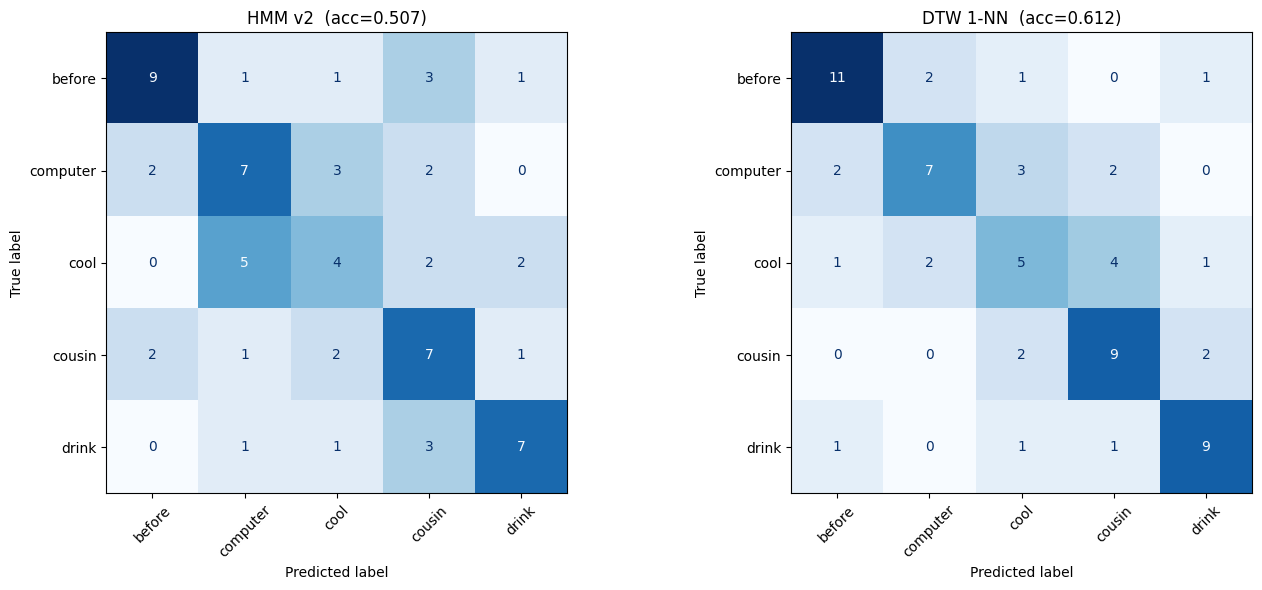

Saved: /workspace/dataset/ipynb_checkpoints/ksl_project_data/reports/hmm_v2_confusion_matrices.png

HMM v2 confusion matrix (rows = true, cols = predicted):
          before  computer  cool  cousin  drink
before         9         1     1       3      1
computer       2         7     3       2      0
cool           0         5     4       2      2
cousin         2         1     2       7      1
drink          0         1     1       3      7


In [21]:
def plot_cm(ax, y_true, y_pred, class_names, title):
    decided = y_pred != -1
    cm = confusion_matrix(y_true[decided], y_pred[decided],
                          labels=list(range(len(class_names))))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap="Blues")
    ax.set_title(title)
    return cm


n_panels = 2 if results["oof_dtw"] is not None else 1
fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 6))
axes = np.atleast_1d(axes)

cm_hmm = plot_cm(axes[0], y_true, results["oof_hmm"], class_names,
                 f"HMM v2  (acc={hmm_metrics['accuracy']:.3f})")
if results["oof_dtw"] is not None:
    plot_cm(axes[1], y_true, results["oof_dtw"], class_names,
            f"DTW 1-NN  (acc={dtw_metrics['accuracy']:.3f})")

plt.tight_layout()
cm_path = REPORT_DIR / "hmm_v2_confusion_matrices.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)
print()
print("HMM v2 confusion matrix (rows = true, cols = predicted):")
print(pd.DataFrame(cm_hmm, index=class_names, columns=class_names))

## 15. Fit the final model on all data and save

The metadata now records per-fold accuracies, the standard deviation, the majority-class
baseline and the DTW comparison, so the artefact documents its own provenance rather
than reporting a single unqualified number.

In [22]:
def fit_final_model(feature_seqs, seq_labels, n_pca=N_PCA_COMPONENTS,
                    n_states=N_HMM_STATES, n_iter=N_ITER):
    le_final = LabelEncoder()
    y = le_final.fit_transform(seq_labels)
    class_ids = list(range(len(le_final.classes_)))

    all_frames = np.vstack(feature_seqs)
    scaler_final = StandardScaler().fit(all_frames)
    n_comp = min(n_pca, all_frames.shape[0], all_frames.shape[1])
    pca_final = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    pca_final.fit(scaler_final.transform(all_frames))

    seqs = [pca_final.transform(scaler_final.transform(s)).astype(np.float64)
            for s in feature_seqs]
    models = fit_class_models(seqs, y, class_ids, n_states, n_iter, verbose=True)

    return {
        "class_models": models,
        "scaler": scaler_final,
        "pca": pca_final,
        "label_encoder": le_final,
        "n_hmm_states": n_states,
        "n_pca_components": n_comp,
        "max_frames": MAX_FRAMES,
        "frame_stride": FRAME_STRIDE,
        "train_transitions": TRAIN_TRANSITIONS,
        "feature_spec": {
            "upper_pose_idx": UPPER_POSE_IDX,
            "n_coord_dims": N_COORD_DIMS,
            "n_base_dims": N_BASE_DIMS,
            "n_full_dims": N_FULL_DIMS,
            "face_included": False,
            "body_centred": True,
            "shoulder_scaled": True,
            "delta_features": True,
        },
    }


logger.info("Fitting final model on all %d sequences...", len(features))
hmm_package = fit_final_model(features, sequence_labels)

package_path = MODEL_DIR / "hmm_wlasl_v2_package.joblib"
joblib.dump(hmm_package, package_path)

metadata = {
    "model": "GaussianHMM per class, left-to-right (Bakis) topology, fixed transitions",
    "notebook": "022_hmm_wlasl_baselin.ipynb",
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "dataset": DATASET_NAME,
    "classes": class_names,
    "n_sequences": int(len(features)),
    "frame_feature_dim": int(N_FULL_DIMS),
    "raw_frame_dim": int(EXPECTED_RAW_DIM),
    "face_landmarks_used": False,
    "n_pca_components": int(hmm_package["n_pca_components"]),
    "n_hmm_states": int(N_HMM_STATES),
    "train_transitions": bool(TRAIN_TRANSITIONS),
    "cv_folds": int(results["n_folds"]),
    "landmark_detection_rate_pct": {k: round(float(v), 2) for k, v in detection.items()},
    "majority_baseline_accuracy": float(majority_acc),
    "hmm": hmm_metrics,
    "hmm_fold_accuracies": results["fold_acc"].tolist(),
    "hmm_fold_accuracy_mean": float(results["fold_acc"].mean()),
    "hmm_fold_accuracy_std": float(results["fold_acc"].std()),
    "dtw_1nn": dtw_metrics,
    "previous_notebook": {"name": "02_hmm_wlasl_baseline.ipynb", "accuracy": 0.2353,
                          "failure": "collapsed to single class via -inf argmax"},
}

metadata_path = MODEL_DIR / "hmm_v2_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

logger.info("Saved model package: %s", package_path)
logger.info("Saved metadata     : %s", metadata_path)

print("Model package:", package_path)
print("Metadata     :", metadata_path)
print()
print(json.dumps({k: v for k, v in metadata.items()
                  if k in ("classes", "n_sequences", "frame_feature_dim",
                           "majority_baseline_accuracy", "hmm_fold_accuracy_mean",
                           "hmm_fold_accuracy_std")}, indent=2))

2026-08-16 12:50:23,321 | INFO    | Fitting final model on all 67 sequences...
2026-08-16 12:50:24,117 | INFO    |   class 0: 15 sequences, 459 frames
2026-08-16 12:50:24,224 | INFO    |   class 1: 14 sequences, 480 frames
2026-08-16 12:50:24,302 | INFO    |   class 2: 13 sequences, 363 frames
2026-08-16 12:50:24,425 | INFO    |   class 3: 13 sequences, 516 frames
2026-08-16 12:50:24,489 | INFO    |   class 4: 12 sequences, 402 frames
2026-08-16 12:50:24,501 | INFO    | Saved model package: /workspace/dataset/ipynb_checkpoints/ksl_project_data/models/hmm_wlasl_v2_package.joblib
2026-08-16 12:50:24,501 | INFO    | Saved metadata     : /workspace/dataset/ipynb_checkpoints/ksl_project_data/models/hmm_v2_metadata.json
Model package: /workspace/dataset/ipynb_checkpoints/ksl_project_data/models/hmm_wlasl_v2_package.joblib
Metadata     : /workspace/dataset/ipynb_checkpoints/ksl_project_data/models/hmm_v2_metadata.json

{
  "classes": [
    "before",
    "computer",
    "cool",
    "cousin",
 

## 16. End-to-end inference on a new video

Loads the saved package and classifies an unseen video file. Returns `None` when no
class scores finitely, rather than guessing - the abstain behaviour that v1 lacked.

In [24]:
def load_package(path=None):
    path = Path(path) if path else (MODEL_DIR / "hmm_wlasl_v2_package.joblib")
    if not path.exists():
        raise CacheMissingError(f"Model package not found at {path}")
    return joblib.load(path)


def predict_video(video_path, package=None, top_k=3):
    """
    Classify one video file end to end.

    Returns a dict with 'label', 'confidence_gap' and a ranked 'scores' list,
    or {'label': None, ...} if the model abstains.
    """
    pkg = package or load_package()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        raw = extract_video_landmark_sequence(
            video_path, max_frames=pkg["max_frames"], frame_stride=pkg["frame_stride"])

    if raw is None or len(raw) < 2:
        logger.warning("[HMM-5001] No usable landmarks in %s", video_path)
        return {"label": None, "reason": "no landmarks detected", "scores": []}

    feats = build_sequence_features(np.asarray(raw, dtype=np.float64))
    reduced = pkg["pca"].transform(pkg["scaler"].transform(feats)).astype(np.float64)

    le_pkg = pkg["label_encoder"]
    class_ids = sorted(pkg["class_models"].keys())
    S = score_matrix([reduced], pkg["class_models"], class_ids)[0]

    if not np.isfinite(S).any():
        logger.warning("[HMM-5002] All classes scored non-finite for %s", video_path)
        return {"label": None, "reason": "no class scored finitely", "scores": []}

    order = np.argsort(np.where(np.isfinite(S), S, -np.inf))[::-1]
    ranked = [(le_pkg.classes_[class_ids[i]], float(S[i])) for i in order
              if np.isfinite(S[i])]

    gap = ranked[0][1] - ranked[1][1] if len(ranked) > 1 else float("inf")
    return {"label": ranked[0][0], "confidence_gap": gap, "scores": ranked[:top_k]}


# --- smoke test on a video we already have ---
_pkg = load_package()
_demo_sample = selected_samples[0]
_truth = get_label_from_sample(_demo_sample)
_out = predict_video(_demo_sample.filepath, package=_pkg)

print("video      :", Path(_demo_sample.filepath).name)
print("true gloss :", _truth)
print("predicted  :", _out["label"])
print("gap        :", round(_out.get("confidence_gap", float('nan')), 4))
print("top scores :")
for lab, sc in _out["scores"]:
    print(f"   {lab:<14s}{sc:10.4f}")
print()
print("NOTE: this video was in the training set, so a correct answer here proves the")
print("      inference path works -- it is NOT a measure of accuracy. Use section 13.")

W0000 00:00:1786884690.174731    3925 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786884690.250363    3925 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786884690.253571    3926 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786884690.253816    3923 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786884690.264416    3925 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786884690.283887    3923 inference_feedback_manager.cc:114] Feedback manager 

video      : 05727.mp4
true gloss : before
predicted  : before
gap        : 8.6986
top scores :
   before          -35.5815
   computer        -44.2800
   cousin          -54.1435

NOTE: this video was in the training set, so a correct answer here proves the
      inference path works -- it is NOT a measure of accuracy. Use section 13.


## 17. Where this stands, and what actually moves the number next

### Interpreting the result

Compare against the **majority-class baseline** printed in section 13, not against zero.
With ~13 sequences per class over 5 classes, a realistic target is **0.45-0.65**.
Anything near 0.90 on this much data would indicate leakage, not skill.

Watch three things in the output:

1. **`Distinct classes predicted`** - must be greater than 1. If it reads 1, the model
   has collapsed again and every other metric is meaningless.
2. **Per-fold standard deviation** - if it exceeds ~0.15, the folds disagree and the
   mean is not trustworthy. Report the spread alongside the mean.
3. **HMM vs DTW** - if DTW wins, say so plainly. At this data scale a zero-parameter
   method beating a parametric one is the expected outcome and a legitimate finding.

### The data is the bottleneck, in this order

1. **Fix the download.** Section 5 shows classes with labelled entries but no files on
   disk. That is ~45 recoverable videos and it is the cheapest win available - audit
   `download_wlasl.py`.
2. **Raise samples per class.** HMMs on small-vocabulary sign start behaving around
   30+ sequences per class. WLASL's tail is thin, so consider augmentation: horizontal
   mirroring (with left/right hand blocks swapped), temporal jitter via variable frame
   stride, and small rotations applied before landmark extraction.
3. **Move to signer-independent splits.** Stratified random splits let the same signer
   appear in train and test, which inflates scores. Group by signer once the WLASL
   metadata is wired up.
4. **Check the detection rates from section 8b.** If a hand is found in under 50% of
   frames, that ceiling binds before any modelling choice does.

### Model knobs worth trying, in order of expected payoff

| Change | Where | Rationale |
|---|---|---|
| `N_HMM_STATES` 3 -> 4 | section 2 | only after samples/class exceeds ~20 |
| `TRAIN_TRANSITIONS = True` | section 2 | only after samples/class exceeds ~30 |
| `N_PCA_COMPONENTS` 16 -> 24 | section 2 | only if per-fold SD is low and accuracy has plateaued |
| Drop the `z` coordinate | section 8 | MediaPipe depth is weakly calibrated and may be pure noise |
| Add second-order deltas | `build_sequence_features` | worth testing once sequences exceed ~50 frames |

Change **one** at a time and re-read section 13. With 5 folds over ~67 sequences the
noise floor is roughly +/- 0.06, so a 2-point improvement is not a result.

### Applies to your other notebooks too

The face-dominance issue (ADR-001) and the zero-fill outlier issue (ADR-002) are
properties of the **shared feature extractor**, not of the HMM. `RandomForest.ipynb`,
`03_lstm_wlasl_landmark_baseline.ipynb`, `04_stgcn_...` and `05_transformer_...` all
consume the same 1629-D vectors and inherit both problems. Porting sections 8 and 8b
into those notebooks is likely to help them more than any architecture change.